In [1]:
from correlation_stability import run_stability_analysis
import scanpy as sc
from run_dgcna_correlation import run_dgcna_analysis
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt



In [2]:
adata=sc.read_loom('Integrated_betas.loom') 
adata.obs_names=adata.obs.obs_names
adata.var_names=adata.var.gene_name

C:\Users\Leo\anaconda3\Lib\functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
C:\Users\Leo\anaconda3\Lib\functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [3]:
len(adata.obs.Donor.unique())

17

In [4]:
adata.obs.batch.value_counts()

batch
dataset2    524
dataset1    514
Name: count, dtype: int64

In [5]:
adata.obs[['Donor','batch','Disease']].drop_duplicates()

,Donor,batch,Disease
obs_names,,,
351,Sample110,dataset1,T2D
352,Sample102,dataset1,normal
358,Sample108,dataset1,T2D
369,Sample109,dataset1,T2D
370,Sample103,dataset1,normal
391,Sample105,dataset1,normal
393,Sample106,dataset1,normal
397,Sample104,dataset1,normal
HP1525901_A14,HP1525901,dataset2,normal


In [6]:
adata.obs.Donor.value_counts()

Donor
HP1602301T2D    101
Sample110       100
HP1525901        79
HP1529801T2D     79
Sample109        76
Sample103        73
Sample105        65
Sample106        61
HP1606401T2D     56
Sample102        51
HP1711701T2D     49
HP1601201T2D     46
Sample104        46
HP1714601        44
Sample108        42
HP1711001        37
HP1605601T2D     33
Name: count, dtype: int64

In [7]:
sel_genes=pd.read_excel("sel_genes.xlsx")
ndcg_genes=sel_genes.Gene_name.unique()
glyco=sel_genes[sel_genes.Module=='(6) Glycolysis'].Gene_name.values

In [8]:
from run_dgcna_correlation import get_lmm_residuals
 
residuals_df, obs_df = get_lmm_residuals(adata, min_cells_per_donor=30)

Kept 17 donors with > 30 cells
Cells: 1038, donors: 17, genes: 12727


In [9]:
edge_df=pd.read_csv('Edges_data.csv', index_col=0)

Using 664 / 671 genes

T2D: 582 cells, sampling 465 per iteration


  Subsampling T2D: 100%|███████████████████████████████████████████████████████████| 1000/1000 [00:11<00:00, 88.73it/s]



normal: 456 cells, sampling 364 per iteration


  Subsampling normal: 100%|████████████████████████████████████████████████████████| 1000/1000 [00:13<00:00, 76.50it/s]



Computing stability metrics for T2D...

Computing stability metrics for normal...

Computing Δr stability (normal − T2D)...


C:\Users\Leo\OneDrive\Work\dGCNA\correlation_stability.py:254: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data_plot, x='group', y='sign_flip_rate', ax=ax,


Saved correlation_stability.png/.pdf


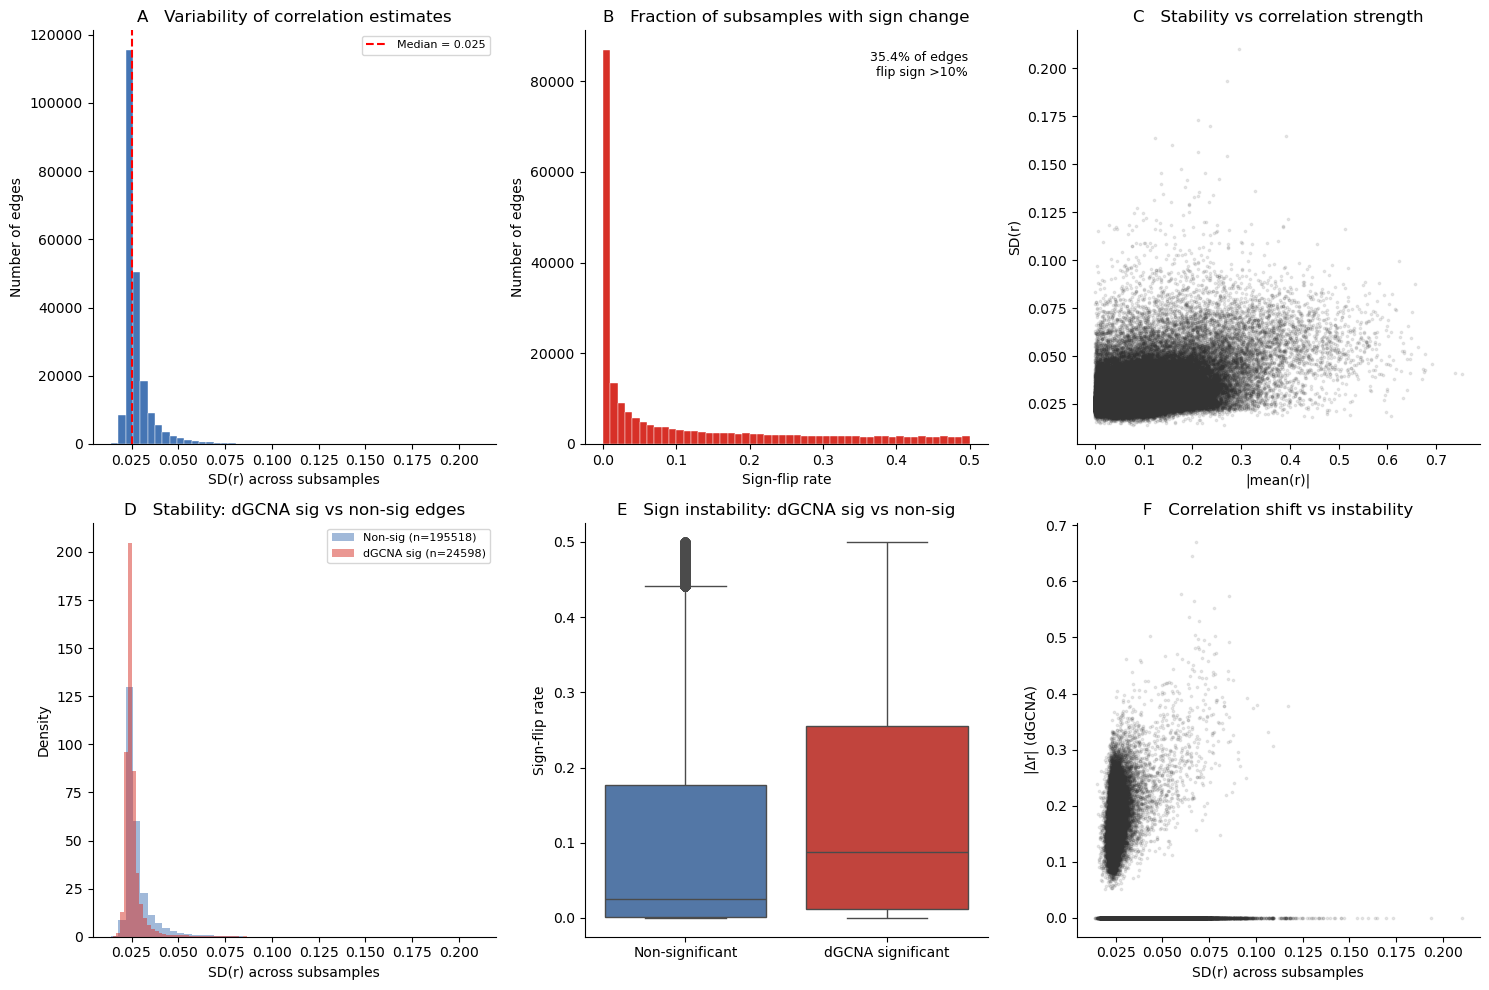


STABILITY SUMMARY (per-condition r)
Total edges analyzed: 220116
Median SD(r): 0.0252
Mean SD(r):   0.0278
Edges with sign-flip rate > 10%: 77839 (35.4%)
Edges with sign-flip rate > 25%: 42007 (19.1%)
Edges with SD(r) > 0.05: 5960 (2.7%)

STABILITY SUMMARY (Δr = r_case − r_ctrl)
Median SD(Δr): 0.0343
Mean SD(Δr):   0.0369
Median 95% CI width: 0.1343
Mean 95% CI width:   0.1447
Edges with Δr sign-flip rate > 10%: 74954 (34.1%)
Edges with Δr sign-flip rate > 25%: 39947 (18.1%)

dGCNA significant edges:
  Median SD(r): 0.0243
  Sign-flip rate (r) > 10%: 11622
  Median SD(Δr): 0.0330
  Median 95% CI width(Δr): 0.1292
  Sign-flip rate (Δr) > 10%: 1 (0.0%)
  Edges where CI width > |Δr|: 4446 (18.1%)
Non-significant edges:
  Median SD(r): 0.0253
  Sign-flip rate (r) > 10%: 66217
  Median SD(Δr): 0.0345
  Median 95% CI width(Δr): 0.1351
  Sign-flip rate (Δr) > 10%: 74953 (38.3%)
  Edges where CI width > |Δr|: 195518 (100.0%)


,gene1,gene2,mean_r,sd_r,iqr_r,sign_flip_rate,pair,delta_r,abs_delta_r,dgcna_significant,mean_delta_r,sd_delta_r,sign_flip_rate_delta_r,ci_lower,ci_upper,ci_width
0,RPS5,RPL11,0.437750,0.064722,0.066894,0.000,"(RPL11, RPS5)",0.000000,0.000000,False,-0.036077,0.075234,0.266,-0.175275,0.133053,0.308328
1,RPS5,RPL35A,0.354645,0.069876,0.088753,0.000,"(RPL35A, RPS5)",0.000000,0.000000,False,0.038161,0.082038,0.326,-0.102123,0.213871,0.315993
2,RPS5,GABARAP,0.382267,0.078057,0.108392,0.000,"(GABARAP, RPS5)",0.000000,0.000000,False,0.041376,0.087546,0.334,-0.094786,0.253795,0.348582
3,RPS5,DSTN,0.318986,0.079457,0.102314,0.007,"(DSTN, RPS5)",0.000000,0.000000,False,0.015795,0.094134,0.493,-0.134986,0.233520,0.368506
4,RPS5,OAZ1,0.255950,0.078490,0.104753,0.009,"(OAZ1, RPS5)",0.000000,0.000000,False,0.000999,0.088752,0.453,-0.152771,0.221842,0.374614
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
220111,LYRM9,UBE2N,0.108041,0.022582,0.029999,0.000,"(LYRM9, UBE2N)",0.000000,0.000000,False,0.022166,0.030411,0.238,-0.033925,0.081914,0.115839
220112,LYRM9,DARS2,-0.025063,0.023431,0.027847,0.113,"(DARS2, LYRM9)",-0.148851,0.148851,True,0.148770,0.030507,0.000,0.088608,0.204418,0.115810
220113,ACADM,UBE2N,0.141867,0.024218,0.032713,0.000,"(ACADM, UBE2N)",0.000000,0.000000,False,0.008100,0.033245,0.405,-0.057715,0.072333,0.130048
220114,ACADM,DARS2,0.076190,0.022251,0.027036,0.000,"(ACADM, DARS2)",0.000000,0.000000,False,0.043707,0.030655,0.079,-0.015851,0.099308,0.115159


In [10]:
# Basic usage - tests stability within each condition
results = run_stability_analysis(
    residuals_df, 
    obs_df,
    genes=ndcg_genes,        # optional: subset to NDCG genes or all
    edge_df=edge_df,        # your existing edge_df to compare sig vs nonsig
    frac=0.8,               # keep 80% of cells per subsample
    n_iter=1000,             # 100 iterations
)
 
# Access results
results['combined_stability']  # per-edge SD(r), sign-flip rate
results['merged']  

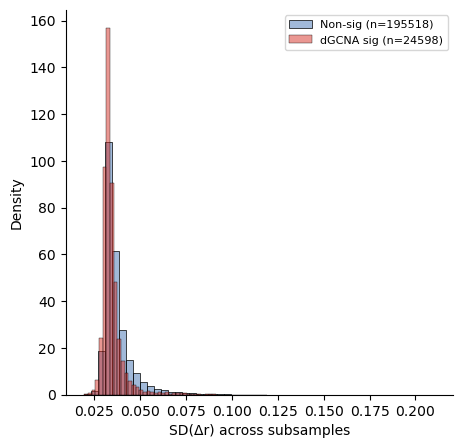

In [11]:
# SD(Δr) for dGCNA significant vs non-significant
fig, ax = plt.subplots(figsize=(5, 5))

merged_df = results['merged'].copy()
sig = merged_df[merged_df['dgcna_significant'] == True]['sd_delta_r']
nonsig = merged_df[merged_df['dgcna_significant'] == False]['sd_delta_r']

sns.histplot(nonsig, bins=50, alpha=0.5, color='#4575b4', label=f'Non-sig (n={len(nonsig)})', ax=ax, stat='density')
sns.histplot(sig, bins=50, alpha=0.5, color='#d73027', label=f'dGCNA sig (n={len(sig)})', ax=ax, stat='density')


ax.set_xlabel('SD(Δr) across subsamples')
ax.set_ylabel('Density')
ax.legend(fontsize=8)
ax.spines[['top', 'right']].set_visible(False)

plt.savefig('Figure2/delta_r_dist.png', dpi=200, bbox_inches='tight')
plt.savefig('Figure2/delta_r_dist.svg', bbox_inches='tight')

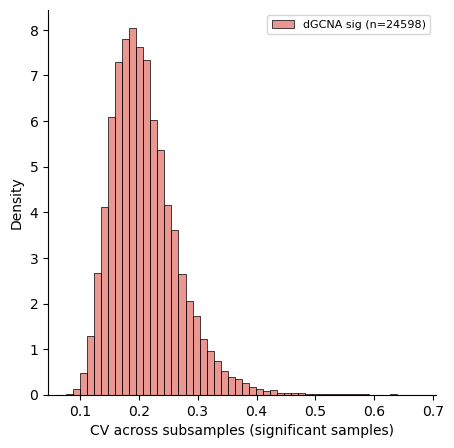

In [12]:
# CV for dGCNA significant vs non-significant
fig, ax = plt.subplots(figsize=(5, 5))

merged_df = results['merged'].copy()
sig = merged_df[merged_df['dgcna_significant'] == True]['sd_delta_r'] / merged_df[merged_df['dgcna_significant'] == True].mean_delta_r.abs()
#nonsig = merged_df[merged_df['dgcna_significant'] == False]['sd_delta_r'] / merged_df[merged_df['dgcna_significant'] == False].mean_delta_r.abs()

#sns.histplot(nonsig, bins=50, alpha=0.5, color='#4575b4', label=f'Non-sig (n={len(nonsig)})', ax=ax, stat='density')
sns.histplot(sig, bins=50, alpha=0.5, color='#d73027', label=f'dGCNA sig (n={len(sig)})', ax=ax, stat='density')


ax.set_xlabel('CV across subsamples (significant samples)')
ax.set_ylabel('Density')
ax.legend(fontsize=8)
ax.spines[['top', 'right']].set_visible(False)

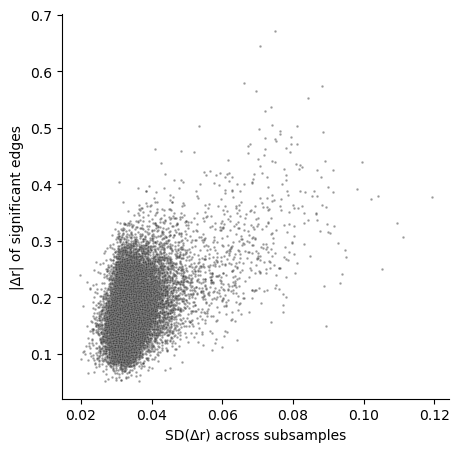

In [13]:
# SD(Δr) for dGCNA significant vs non-significant
fig, ax = plt.subplots(figsize=(5, 5))

merged_df = results['merged'].copy()
sig = merged_df[merged_df['dgcna_significant'] == True]

sns.scatterplot(sig, x='sd_delta_r', y='abs_delta_r', alpha=0.5, s=3, color='#333333')

ax.set_ylabel('|Δr| of significant edges')
ax.set_xlabel('SD(Δr) across subsamples')

plt.savefig('Figure2/delta_r_vs_sd.png', dpi=200, bbox_inches='tight')
plt.savefig('Figure2/delta_r_vs_sd.svg', bbox_inches='tight')

sns.despine()

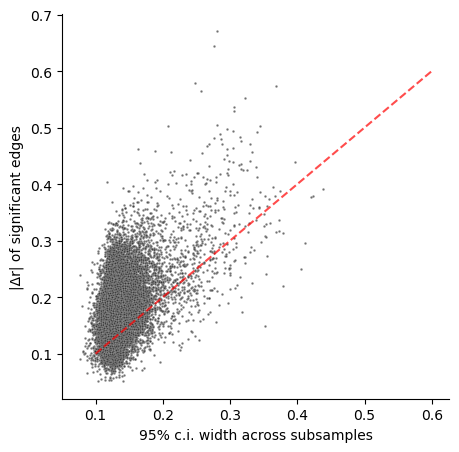

In [14]:
# SD(Δr) for dGCNA significant vs non-significant
fig, ax = plt.subplots(figsize=(5, 5))

merged_df = results['merged'].copy()
sig = merged_df[merged_df['dgcna_significant'] == True]

sns.scatterplot(sig, x='ci_width', y='abs_delta_r', alpha=0.7, s=3, color='#333333')
sns.lineplot(x=[0.1,0.6],y=[0.1,0.6], linestyle='--', c='r', alpha=0.7)

ax.set_xlabel('95% c.i. width across subsamples')
ax.set_ylabel('|Δr| of significant edges')


sns.despine()

plt.savefig('Figure2/delta_r_vs_ci.png', dpi=200, bbox_inches='tight')
plt.savefig('Figure2/delta_r_vs_ci.svg', bbox_inches='tight')

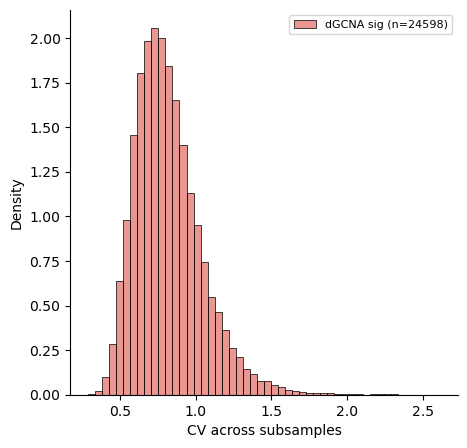

In [15]:
# CV for dGCNA significant vs non-significant
fig, ax = plt.subplots(figsize=(5, 5))

merged_df = results['merged'].copy()
sig = merged_df[merged_df['dgcna_significant'] == True]['ci_width'] / merged_df[merged_df['dgcna_significant'] == True].mean_delta_r.abs()
#nonsig = merged_df[merged_df['dgcna_significant'] == False]['sd_delta_r'] / merged_df[merged_df['dgcna_significant'] == False].mean_delta_r.abs()

#sns.histplot(nonsig, bins=50, alpha=0.5, color='#4575b4', label=f'Non-sig (n={len(nonsig)})', ax=ax, stat='density')
sns.histplot(sig, bins=50, alpha=0.5, color='#d73027', label=f'dGCNA sig (n={len(sig)})', ax=ax, stat='density')


ax.set_xlabel('CV across subsamples')
ax.set_ylabel('Density')
ax.legend(fontsize=8)
ax.spines[['top', 'right']].set_visible(False)

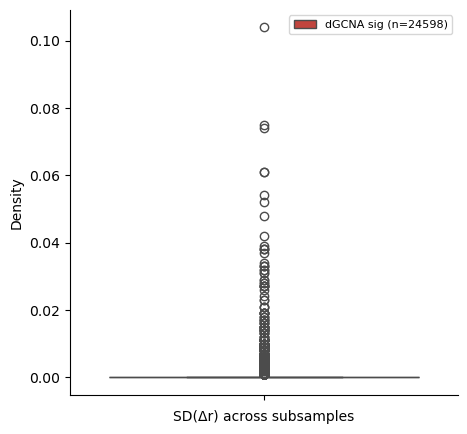

In [16]:
# SD(Δr) for dGCNA significant vs non-significant
fig, ax = plt.subplots(figsize=(5, 5))

merged_df = results['merged'].copy()
sig = merged_df[merged_df['dgcna_significant'] == True]['sign_flip_rate_delta_r']
nonsig = merged_df[merged_df['dgcna_significant'] == False]['sign_flip_rate_delta_r']

#sns.histplot(nonsig, bins=50, alpha=0.5, color='#4575b4', label=f'Non-sig (n={len(nonsig)})', ax=ax, stat='density')
#sns.histplot(sig, bins=50, alpha=0.5, color='#d73027', label=f'dGCNA sig (n={len(sig)})', ax=ax, stat='density')
sns.boxplot(sig, color='#d73027', label=f'dGCNA sig (n={len(sig)})', ax=ax)
#sns.boxplot(nonsig, color='#d73027', label=f'dGCNA sig (n={len(sig)})', ax=ax)


ax.set_xlabel('SD(Δr) across subsamples')
ax.set_ylabel('Density')
ax.legend(fontsize=8)
ax.spines[['top', 'right']].set_visible(False)

In [17]:
(sig>0).sum()/len(sig) *100

np.float64(6.935523213269372)

In [18]:
results.keys()#['combined_stability']

dict_keys(['corr_samples', 'stability', 'combined_stability', 'delta_stability', 'merged'])

In [19]:
len(results['merged'][(results['merged'].dgcna_significant==True)  & (results['merged'].sign_flip_rate>0.1) ]  ) / len(results['merged'][(results['merged'].dgcna_significant==True)]) *100


47.24774371900155

In [20]:
len(results['merged'][(results['merged'].dgcna_significant==True)  & (results['merged'].sign_flip_rate>0.25) ]  ) / len(results['merged'][(results['merged'].dgcna_significant==True)]) *100


25.579315391495243